In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset
df = pd.read_csv("employee_attrition_dataset_10000.csv")
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,...,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,...,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,...,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,...,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,...,No,1,54,11,1,1,1,43,4,No


In [3]:
 df.shape

(10000, 26)

In [4]:
df.columns

Index(['Employee_ID', 'Age', 'Gender', 'Marital_Status', 'Department',
       'Job_Role', 'Job_Level', 'Monthly_Income', 'Hourly_Rate',
       'Years_at_Company', 'Years_in_Current_Role',
       'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction',
       'Performance_Rating', 'Training_Hours_Last_Year', 'Overtime',
       'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism',
       'Work_Environment_Satisfaction', 'Relationship_with_Manager',
       'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked',
       'Attrition'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    10000 non-null  int64 
 1   Age                            10000 non-null  int64 
 2   Gender                         10000 non-null  object
 3   Marital_Status                 10000 non-null  object
 4   Department                     10000 non-null  object
 5   Job_Role                       10000 non-null  object
 6   Job_Level                      10000 non-null  int64 
 7   Monthly_Income                 10000 non-null  int64 
 8   Hourly_Rate                    10000 non-null  int64 
 9   Years_at_Company               10000 non-null  int64 
 10  Years_in_Current_Role          10000 non-null  int64 
 11  Years_Since_Last_Promotion     10000 non-null  int64 
 12  Work_Life_Balance              10000 non-null  int64 
 13  Jo

In [6]:
df.isnull().sum()

Employee_ID                      0
Age                              0
Gender                           0
Marital_Status                   0
Department                       0
Job_Role                         0
Job_Level                        0
Monthly_Income                   0
Hourly_Rate                      0
Years_at_Company                 0
Years_in_Current_Role            0
Years_Since_Last_Promotion       0
Work_Life_Balance                0
Job_Satisfaction                 0
Performance_Rating               0
Training_Hours_Last_Year         0
Overtime                         0
Project_Count                    0
Average_Hours_Worked_Per_Week    0
Absenteeism                      0
Work_Environment_Satisfaction    0
Relationship_with_Manager        0
Job_Involvement                  0
Distance_From_Home               0
Number_of_Companies_Worked       0
Attrition                        0
dtype: int64

In [7]:
df.describe()

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,39.561800,2.990800,11436.716700,57.032300,14.936200,7.451300,4.471900,2.502400,3.038000,2.507700,49.588900,4.984400,44.473500,9.410200,2.493100,2.491400,2.505400,25.272000,2.516600
std,2886.89568,11.454986,1.410643,4926.528302,24.703261,8.431657,4.042903,2.891617,1.112348,1.414764,1.120833,28.801393,2.580043,8.611662,5.760335,1.120927,1.115101,1.116018,14.219474,1.113934
min,1.00000,20.000000,1.000000,3000.000000,15.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,30.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2500.75000,30.000000,2.000000,7182.500000,36.000000,8.000000,4.000000,2.000000,2.000000,2.000000,2.000000,25.000000,3.000000,37.000000,4.000000,1.000000,1.000000,2.000000,13.000000,2.000000
50%,5000.50000,40.000000,3.000000,11401.500000,57.000000,15.000000,7.000000,4.000000,2.000000,3.000000,3.000000,49.000000,5.000000,45.000000,9.000000,2.000000,2.000000,3.000000,25.000000,2.000000
75%,7500.25000,49.000000,4.000000,15679.500000,78.000000,22.000000,11.000000,7.000000,3.000000,4.000000,4.000000,75.000000,7.000000,52.000000,14.000000,4.000000,3.000000,3.000000,37.000000,4.000000
max,10000.00000,59.000000,5.000000,19999.000000,99.000000,29.000000,14.000000,9.000000,4.000000,5.000000,4.000000,99.000000,9.000000,59.000000,19.000000,4.000000,4.000000,4.000000,49.000000,4.000000


In [8]:
# Checking target column distribution
df['Attrition'].value_counts()

Attrition
No     8003
Yes    1997
Name: count, dtype: int64

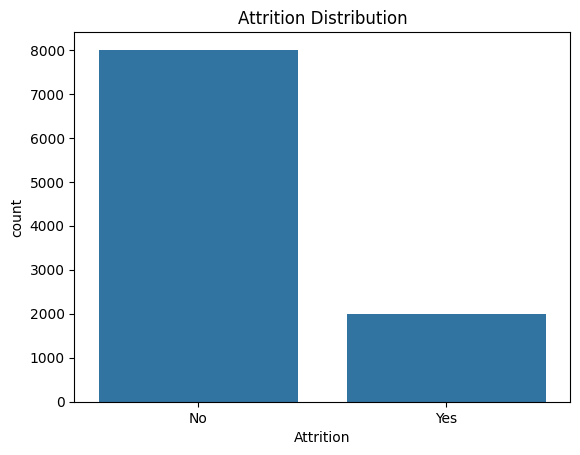

In [9]:
sns.countplot(x='Attrition', data=df)
plt.title("Attrition Distribution")
plt.show()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime',
       'Attrition'],
      dtype='object')


In [12]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,1,2,0,3,5,7332,81,24,...,0,9,48,16,4,1,1,49,3,0
1,2,48,0,0,1,1,4,6069,55,18,...,1,9,57,10,4,1,1,25,1,0
2,3,34,0,1,3,3,4,11485,65,6,...,1,3,55,1,1,4,3,21,1,1
3,4,27,0,0,1,3,4,18707,28,12,...,0,9,53,2,3,4,1,46,2,0
4,5,40,1,1,1,0,1,16398,92,3,...,0,1,54,11,1,1,1,43,4,0


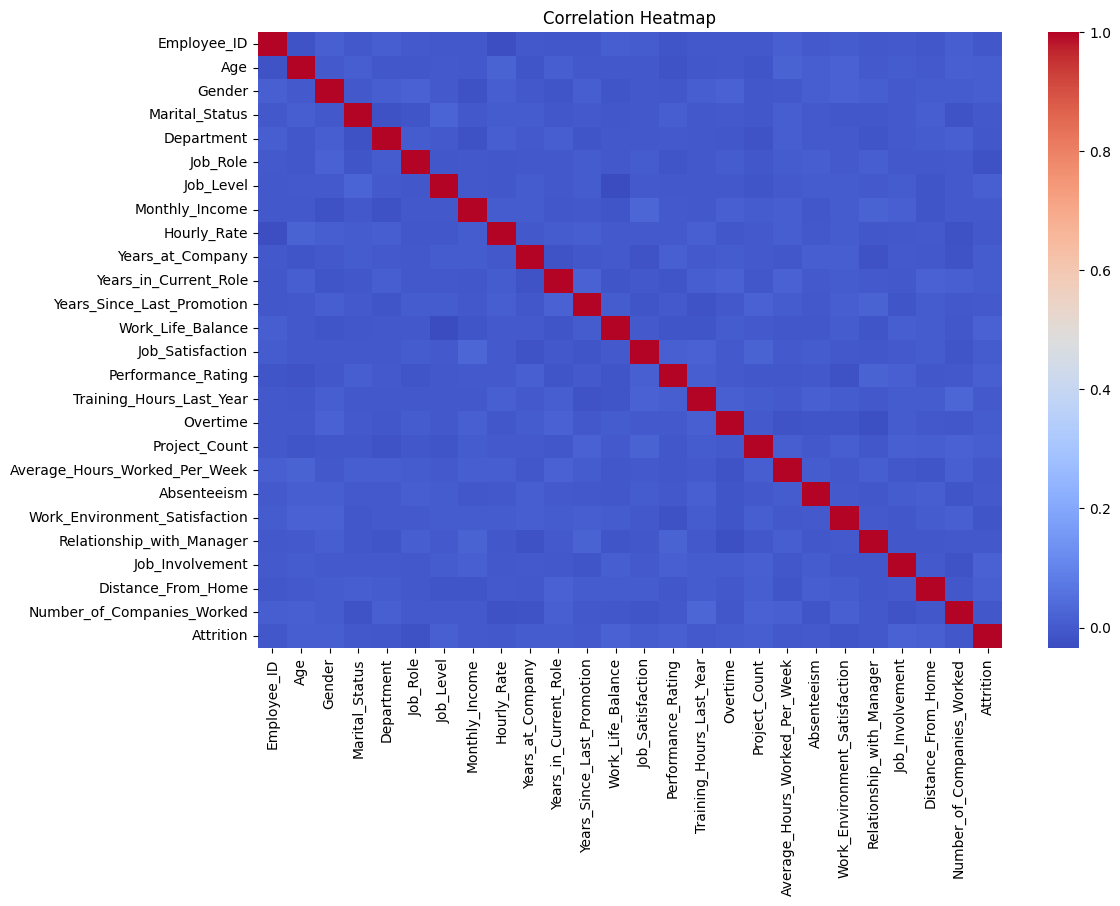

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [14]:
# Income per experience
df['Income_per_Year'] = df['Monthly_Income'] / (df['Years_at_Company'] + 1)

# Work stress indicator
df['Work_Stress'] = df['Average_Hours_Worked_Per_Week'] * df['Project_Count']

# Promotion gap
df['Promotion_Gap'] = df['Years_Since_Last_Promotion'] / (df['Years_at_Company'] + 1)

df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition,Income_per_Year,Work_Stress,Promotion_Gap
0,1,58,1,2,0,3,5,7332,81,24,...,16,4,1,1,49,3,0,293.280000,432,0.120000
1,2,48,0,0,1,1,4,6069,55,18,...,10,4,1,1,25,1,0,319.421053,513,0.263158
2,3,34,0,1,3,3,4,11485,65,6,...,1,1,4,3,21,1,1,1640.714286,165,0.428571
3,4,27,0,0,1,3,4,18707,28,12,...,2,3,4,1,46,2,0,1439.000000,477,0.076923
4,5,40,1,1,1,0,1,16398,92,3,...,11,1,1,1,43,4,0,4099.500000,54,0.250000


In [15]:
# Correlation with target
corr = df.corr()['Attrition'].sort_values(ascending=False)
print(corr)

Attrition                        1.000000
Work_Life_Balance                0.015227
Job_Involvement                  0.014954
Performance_Rating               0.011856
Job_Level                        0.011415
Distance_From_Home               0.011361
Age                              0.007798
Gender                           0.007448
Project_Count                    0.006802
Work_Stress                      0.005230
Years_in_Current_Role            0.005120
Years_at_Company                 0.002682
Overtime                         0.002537
Job_Satisfaction                 0.002142
Absenteeism                      0.000514
Monthly_Income                   0.000135
Training_Hours_Last_Year        -0.000539
Years_Since_Last_Promotion      -0.001936
Average_Hours_Worked_Per_Week   -0.002457
Marital_Status                  -0.003998
Relationship_with_Manager       -0.004111
Promotion_Gap                   -0.005366
Hourly_Rate                     -0.005494
Income_per_Year                 -0

In [16]:
# Drop ID column (not useful for prediction)
df = df.drop('Employee_ID', axis=1)

In [17]:
# Features (X) and Target (y)
#X = df.drop('Attrition', axis=1)
#y = df['Attrition']

#print("X shape:", X.shape)
#print("y shape:", y.shape)

In [18]:
X = df[[
    'Age',
    'Monthly_Income',
    'Years_at_Company',
    'Job_Satisfaction',
    'Work_Life_Balance',
    'Performance_Rating',
    'Project_Count',
    'Average_Hours_Worked_Per_Week',
    'Income_per_Year',
    'Work_Stress',
    'Promotion_Gap'
]]

y = df['Attrition']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 11)
y shape: (10000,)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (8000, 11)
Test size: (2000, 11)


In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
print(y.value_counts())

Attrition
0    8003
1    1997
Name: count, dtype: int64


In [22]:
#import sys
#print(sys.executable)

In [23]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train, y_train = sm.fit_resample(X_train, y_train)

print("After SMOTE:", pd.Series(y_train).value_counts())

After SMOTE: Attrition
1    6411
0    6411
Name: count, dtype: int64


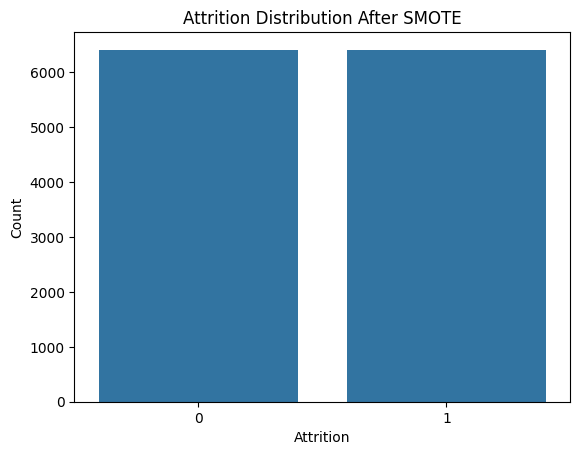

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Countplot after SMOTE
sns.countplot(x=y_train)

plt.title("Attrition Distribution After SMOTE")
plt.xlabel("Attrition")
plt.ylabel("Count")

plt.show()

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [26]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.4905
              precision    recall  f1-score   support

           0       0.80      0.48      0.60      1592
           1       0.20      0.52      0.29       408

    accuracy                           0.49      2000
   macro avg       0.50      0.50      0.45      2000
weighted avg       0.68      0.49      0.54      2000



In [27]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7765
              precision    recall  f1-score   support

           0       0.79      0.97      0.87      1592
           1       0.16      0.02      0.04       408

    accuracy                           0.78      2000
   macro avg       0.48      0.50      0.46      2000
weighted avg       0.66      0.78      0.70      2000



In [28]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.796
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1592
           1       0.50      0.00      0.00       408

    accuracy                           0.80      2000
   macro avg       0.65      0.50      0.45      2000
weighted avg       0.74      0.80      0.71      2000



In [29]:
print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("XGB Accuracy:", accuracy_score(y_test, y_pred_xgb))

LR Accuracy: 0.4905
RF Accuracy: 0.7765
XGB Accuracy: 0.796


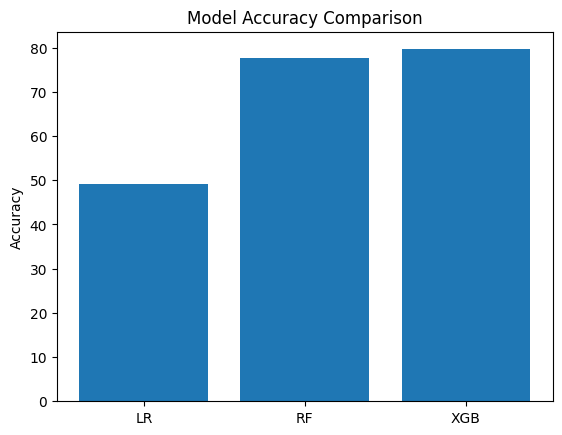

In [34]:
models = ['LR', 'RF', 'XGB']
acc = [49.05, 77.65, 79.6]

plt.bar(models, acc)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

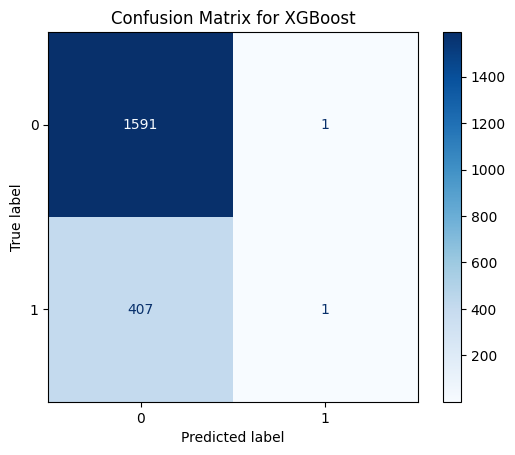

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prediction using XGBoost
y_pred = xgb.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title("Confusion Matrix for XGBoost")
plt.show()

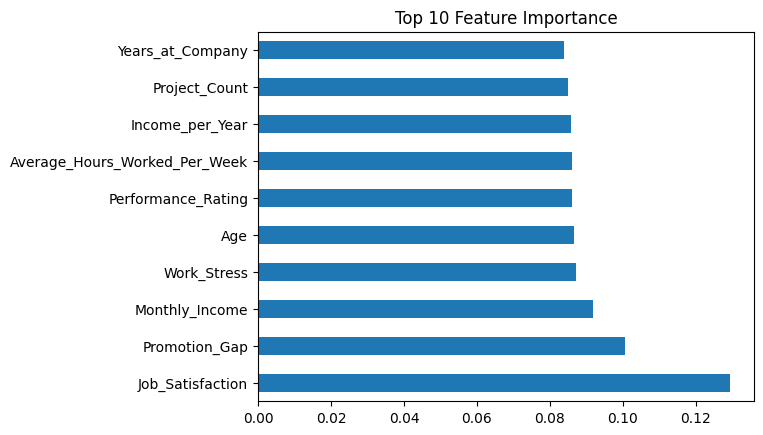

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance from Random Forest
importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# Plot
feat_imp.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importance")
plt.show()

In [32]:
import pickle

# Save model
pickle.dump(rf, open("model.pkl", "wb"))

# Save scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))